# ENGR 1451/2451 — Weekly Assignment 4
**10 points**

This assignment applies measurement-error ideas, pandas data manipulation, and scatterplots and time trends.

**Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested.

## What to hand in

Work this assignment with the **course tutor** in the class project. Use the course tutor as your AI help for this assignment; it keeps the record for you, so you do not need to write a separate log.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To continue later, start a new chat in the same project, state which assignment you are working on and where you stopped, and continue from there. Paste the new session record below the previous one.

Session records are not graded for correctness or for how much help you needed. The code and written answers must still be your own.

## Setup

All data are synthetic teaching examples. LE4-1 and LE4-2 use data embedded in this notebook.
For LE4-3 and LE4-4, place the supplied `buildings.csv` file in a `data/` subfolder beside this notebook:

```text
LE04.ipynb
data/
    buildings.csv
```

Run the notebook with its containing folder as the working directory so that
`data/buildings.csv` points to the supplied file.

Use sample standard deviation $s$ (`ddof=1`). Select rows by conditions, not row positions,
and calculate counts and the latest year from the data. Use the supplied settings for thresholds.

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

## LE4-1. Comparing two measuring instruments (2 pts)

Two instruments repeatedly measure the same reference block. Treat its certified length,
**25.000 mm**, as exact for this exercise.

### A. Precision and estimated bias (1 pt)

Create a table showing the **mean**, **sample standard deviation**, and **estimated bias**
for each instrument. Here, estimated bias is the sample mean minus the reference length.
Which instrument is more precise? Which sample mean is closer to the reference?

**Answer:** The mean of device B matches the reference perfectly, and in turn has an "estimated bias" of 0. Looking at the standard deviations, device B is over four times higher than device A, suggesting that the precision and repeatability is higher in device A, though it has a higher calculated "estimated bias".

In [13]:
reference_mm = 25.000
calibration = pd.DataFrame({
    "A_mm": [25.12, 25.10, 25.14, 25.11, 25.13,
             25.09, 25.12, 25.11, 25.13, 25.10],
    "B_mm": [24.92, 25.06, 24.97, 25.12, 24.89,
             25.03, 25.08, 24.95, 25.00, 24.98],
})

# Your summary table here. Report lengths, s, and estimated bias in mm.

data_device_A = calibration["A_mm"]
data_device_B = calibration["B_mm"]

def summary_table_AB(data_A, data_B):
    mean_A, std_A = data_A.mean(), data_A.std()
    mean_B, std_B = data_B.mean(), data_B.std()
    est_bias_A, est_bias_B = mean_A-reference_mm, mean_B-reference_mm
    
    summary_table = pd.DataFrame({
        "Measuring Device": ["A","B"],
        "Mean": [mean_A, mean_B],
        "Sample STD": [std_A, std_B],
        "Estimated Bias": [est_bias_A, est_bias_B]
    })
    return summary_table

table_uncalibrated = summary_table_AB(data_device_A, data_device_B)
table_uncalibrated.head()

,Measuring Device,Mean,Sample STD,Estimated Bias
0,A,25.115,0.015811,0.115
1,B,25.000,0.072725,0.000


### B. Apply a calibration correction (1 pt)

Subtract A's estimated bias from every A reading and store the result in `corrected_A`.
Compare its mean and sample $s$ with the original A readings.

What changed, and what stayed the same? Would simply collecting more **uncorrected**
readings remove a persistent bias?

**Answer:** Standard deviations stayed the same, which makes sense as we only added/removed a constant from our dataset. The corrected mean for A is now matching our reference measurement, which suggests a more repeatable and consistent bias in device A. Since it seems that device A is consistently off by the same amount, more uncorrected measurements will not remove the bias from the mean.

In [14]:
# Your correction and comparison here

estimated_bias_A, estimated_bias_B = table_uncalibrated["Estimated Bias"][0], table_uncalibrated["Estimated Bias"][0]

corrected_A, corrected_B = data_device_A - estimated_bias_A, data_device_B - estimated_bias_B

calibrated_table = summary_table_AB(corrected_A, corrected_B).drop("Estimated Bias", axis = 1)
calibrated_table.head()


,Measuring Device,Mean,Sample STD
0,A,25.000,0.015811
1,B,24.885,0.072725


## LE4-2. Investigating unusual resistance readings (3 pts)

An instrument repeatedly measures the same nominal 100-ohm resistor under stable conditions.
Its exact resistance is unknown. An independent equipment log documents a **loose electrical
lead during one reading**; the other readings have no documented fault.

### A. Flag observations for investigation (1 pt)

Calculate $Q_1$, $Q_3$, and the IQR. Flag readings outside
$[Q_1-1.5\,\mathrm{IQR},\ Q_3+1.5\,\mathrm{IQR}]$ with a Boolean mask called `is_outlier`.
Display their reading IDs, resistance values, and log status. Use `.loc[]` and retain the original data.

In [15]:
resistance_values = np.array([
    100.1, 99.9, 100.0, 100.2, 100.1, 99.8, 100.0, 100.1, 102.4, 99.9,
    100.2, 100.0, 99.8, 100.1, 100.0, 100.2, 100.1, 101.1, 99.9, 100.0,
])
log_status = [
    "none", "none", "none", "none", "none", "none", "none", "none", "loose_lead", "none",
    "none", "none", "none", "none", "none", "none", "none", "none", "none", "none",
]
readings = pd.DataFrame({
    "reading_id": [f"R{number:02d}" for number in range(1, len(resistance_values) + 1)],
    "resistance_ohm": resistance_values,
    "log_status": log_status,
})
resistance_settings = {
    "outlier_multiplier": 1.5,
    "fault_status": "loose_lead",
    "lower_ohm": 99.8,
    "upper_ohm": 100.2,
}

# Your IQR calculation, Boolean mask, and flagged-reading table here
Q1 = readings["resistance_ohm"].quantile(0.25)
Q3 = readings["resistance_ohm"].quantile(0.75)
iqr = Q3-Q1

is_outlier = (resistance_values < Q1 - resistance_settings["outlier_multiplier"]*iqr) | (resistance_values > Q3 + resistance_settings["outlier_multiplier"]*iqr)
outliers = readings.loc[is_outlier]

outliers.head()

,reading_id,resistance_ohm,log_status
8,R09,102.4,loose_lead
17,R18,101.1,none


### B. Exclude a documented failure (1 pt)

Create `retained_readings` by excluding **only the reading with the logged loose lead**.
Select it by `log_status`, not by its row position or resistance value.
Compare the count, mean, and sample $s$ for all readings and the retained readings in one table.

Compare the absolute changes, in ohms, in the mean and $s$. Which is larger?
Does an IQR flag alone justify excluding the other unusual reading? Explain briefly.

**Answer:** The readings before the true outlier is excluded produce a mean of 100.195, and after excluding the faulty test, the mean is 100.078 which is closer to the 100Ohm that the resistors are supposed to be. The IQR flag alone does not justify excluding the other readings, as they are likely manufacturer error which is important to account for and take note of. The bad test can be removed as it is not an innate property of any resistors.

In [16]:
# Your retained subset and summary comparison here
retained_readings = readings.loc[readings["log_status"] != resistance_settings["fault_status"]]

retain_summary = retained_readings["resistance_ohm"].agg(["mean","std"])
readings_summary = readings["resistance_ohm"].agg(["mean","std"])
retain_mean, retain_std = retain_summary["mean"], retain_summary["std"]
readings_mean, readings_std = readings_summary["mean"], readings_summary["std"]

print(f"Retain mean: {retain_mean}, retain std: {retain_std}")
print(f"Total mean: {readings_mean}, total std: {readings_std}")

Retain mean: 100.07894736842105, retain std: 0.2760413563387848
Total mean: 100.195, total std: 0.5844250435932294


### C. Check a normal approximation (1 pt)

Use **all retained readings from Part B**, including any still flagged by the IQR rule.
Fit a normal model using their calculated mean and sample $s$.

For the interval **99.8 to 100.2 ohms, including both endpoints**, report the observed
percentage using a Boolean mask and the normal-model percentage using `norm.cdf()`.
Is the model percentage too low, too high, or close for this interval?
Why would even a good normal fit fail to establish that the instrument is unbiased?

**Answer:** The observed percentage using a boolean mask is 90%, while it is only 51% using a normal distribution. This is due to the standard deviation being very small, but the quartiles are larger. This makes the range found by the normal approximation much smaller than the true amount found by the boolean mask. This shows that with our sample size, the distribution for actual resistor values is not a normal distribution. A good normal fit could fail to establish that the instrument is unbiased due to the fact that the bias may always be within one std, and fall well within Q1 and Q3 ranges.

In [17]:
# Your observed percentage and normal approximation here
model = norm(loc=retain_mean, scale=retain_std)

lower = resistance_settings["lower_ohm"]
upper = resistance_settings["upper_ohm"]

interval_mask = (resistance_values >= lower) & (resistance_values <= upper)

total = len(resistance_values)
count_mask = 0
for val in interval_mask:
    if val:
        count_mask += 1

percentage_normal = model.sf(lower) - model.sf(upper)

print(f"Percentage within range (mask): {(count_mask/total)*100}%")
print(f"Percentage within range (normal): {(percentage_normal)*100}%")

Percentage within range (mask): 90.0%
Percentage within range (normal): 51.33778920512899%


## LE4-3. Build an electricity-use comparison table (3 pts)

Each row in `data/buildings.csv` describes **one building in one year**. `floor_area_m2` is floor area in
square meters, and `electricity_kWh` is total electricity used during that year.

### A. Create a column and select a year (1 pt)

Run the code below to read `data/buildings.csv` into `buildings`.
Use `.assign()` to create a DataFrame called `energy`
with a new column, `energy_intensity`, calculated as

$$
\text{energy intensity} = \frac{\text{electricity use (kWh)}}{\text{floor area (m}^2\text{)}}.
$$

Find the latest year in the data and create `latest`, a copy containing that year only.
Display building name, use, floor area, and energy intensity for this snapshot.

In [18]:
buildings = pd.read_csv("data/buildings.csv")

energy_settings = {
    "minimum_area_m2": 3000,
    "high_intensity_kWh_m2": 180,
    "trend_building": "Maple",
}

# Your derived column, latest-year selection, and display here

# Find latest year
latest_year = buildings["year"].max()

# Filter by latest year
latest = buildings.loc[buildings["year"] == latest_year]

# Assign an energy intensity column
latest = latest.assign(energy_intensity = latest["electricity_kWh"]/latest["floor_area_m2"])

latest.head()

,building,use,year,floor_area_m2,electricity_kWh,energy_intensity
0,Birch,Office,2025,400,64000,160.0
3,Cedar,Laboratory,2025,1200,228000,190.0
6,Maple,Office,2025,3200,352000,110.0
9,Oak,Laboratory,2025,8000,1760000,220.0
12,Pine,Office,2025,16000,1440000,90.0


### B. Filter and sort (1 pt)

From `latest`, select buildings with floor area **at least 3,000 m²** and energy intensity
**greater than 180 kWh/m²** for the year. Use a compound Boolean condition with `.loc[]`.
Show `building`, `use`, and `energy_intensity`, sorted from highest to lowest intensity.

In [19]:
# Your filtered and sorted table here
min_sqm = 3000
min_energy_intensity = 180

# Filter data and drop extraneous rows
latest_filtered = latest.loc[(latest["floor_area_m2"] >= min_sqm) & (latest["energy_intensity"] > min_energy_intensity)]
latest_filtered = latest.drop(["year", "electricity_kWh", "floor_area_m2"], axis=1)

# Sort highest to lowest
latest_filtered = latest_filtered.sort_values("energy_intensity", ascending=False)

latest_filtered.head()

,building,use,energy_intensity
9,Oak,Laboratory,220.0
3,Cedar,Laboratory,190.0
15,Willow,Laboratory,190.0
0,Birch,Office,160.0
6,Maple,Office,110.0


### C. Group and summarize (1 pt)

Using **all buildings in `latest`**, create one row per building `use` with the number
of buildings and mean energy intensity. Use `.groupby(...).agg(...)` with descriptive column names.

Which use has the larger mean? Does this calculation give equal weight to each building
or to each square meter of floor area?

**Answer:** The laboratory has a higher mean energy intensity. This gives equal weight to each building as it takes an average of the already computed intensity values for each building.

In [20]:
# Your grouped summary here
grouped_latest = latest.groupby("use").agg(row_count = ("energy_intensity","size"), mean_energy_intensity=("energy_intensity","mean"))
grouped_latest.head()

,row_count,mean_energy_intensity
use,,
Laboratory,3,200.0
Office,3,120.0


## LE4-4. Show a relationship and a time trend (2 pts)

Use `energy` and `latest` from LE4-3. Label axes with units and give each plot a title.

### A. Scatterplot with a log axis (1 pt)

For **all buildings in `latest`**, plot floor area on the x-axis and energy intensity
on the y-axis. Use `ax.set_xscale("log")` because floor areas span a wide range.

Explain what equal horizontal distances represent. Does the largest building have the
highest energy intensity in this snapshot?

**Answer:** An equal horizontal distance between two sets of points represents a factor of 10 increase, so 10 to 100 or 100 to 1000 etc. The largest building does not have the highest energy intensity, the third largest does in this case.

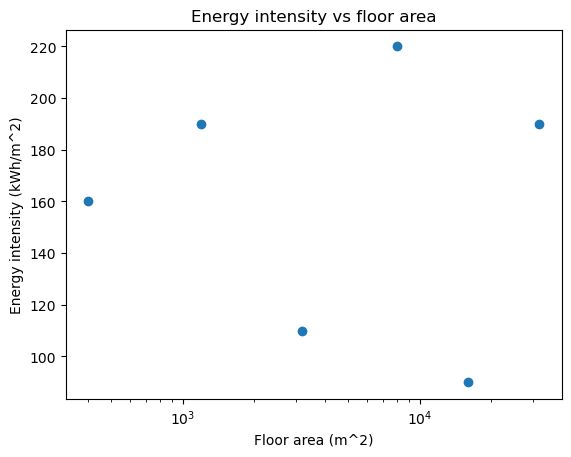

In [21]:
# Your scatterplot here
fig, ax = plt.subplots()
ax.scatter(latest["floor_area_m2"],latest["energy_intensity"])
ax.set_xlabel("Floor area (m^2)")
ax.set_ylabel("Energy intensity (kWh/m^2)")
ax.set_title("Energy intensity vs floor area")
ax.set_xscale("log")

plt.show()

### B. Follow one building over time (1 pt)

From the full `energy` table, select the building named in `energy_settings["trend_building"]`.
Sort its rows by year before making a line plot of energy intensity versus year, with a marker
at each observed year. Use a linear year axis.

Describe the trend. Would this plot alone establish that an energy-saving renovation caused
the change? Give one reason for your answer.

**Answer:** There is a pretty negative linear trend in the data. Energy intensity goes down per year. I do not think that this plot alone establishes an energy saving renovation, as many factors can influence energy usage. The building could have metered its energy uses, dissalowed small appliances, or changed their hours of operation, all of which could possibly be reasons that the energy intensity went down.

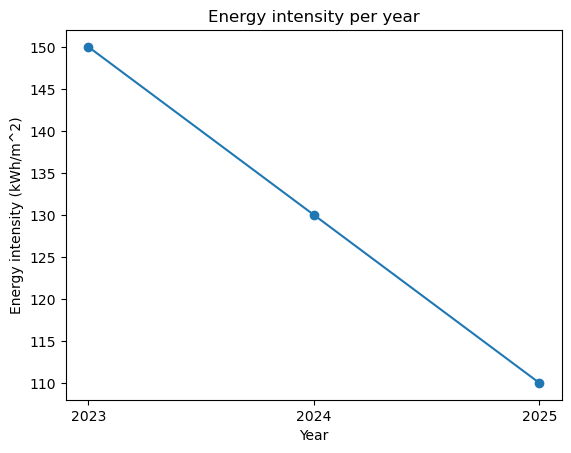

In [22]:
# Your selected, sorted data and time plot here
selected_data = buildings.loc[buildings["building"] == energy_settings["trend_building"]].sort_values("year", ascending=False)
selected_data = selected_data.assign(energy_intensity=selected_data["electricity_kWh"]/selected_data["floor_area_m2"])

fig, ax = plt.subplots()

ax.plot(selected_data["year"], selected_data["energy_intensity"], marker="o")
ax.set_xticks(sorted(selected_data["year"].unique()))
ax.set_xlabel("Year")
ax.set_ylabel("Energy intensity (kWh/m^2)")
ax.set_title("Energy intensity per year")

plt.show()

## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.

<!-- Paste your session record blocks in this cell, one after another. -->
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA4",
  "export_n": 1,
  "session_date": "2026-09-29",
  "messages": [
    {"i": 1, "who": "student", "text": "how do you drop a column from a dataframe by name"},
    {"i": 2, "who": "tutor", "text": "Explained .drop(), axis=1/columns=, returns new DataFrame by default, inplace=True, KeyError on missing names, del df[...] alternative. Asked what's prompting this in buildings/latest."},
    {"i": 3, "who": "student", "text": "what about finding the max value of a column"},
    {"i": 4, "who": "tutor", "text": "Explained .max()/.min(), .idxmax() for the row, comparing column to its own max to see ties, NaN handling. Noted relevance to LE4-3A (latest year) and corrected a mix-up referencing LE5-3A. Asked if working on that step now."},
    {"i": 5, "who": "student", "text": "what about sorting by a specific column"},
    {"i": 6, "who": "tutor", "text": "Explained .sort_values(), ascending default, ascending=False, multi-column sort with list, inplace vs reassign, reset_index(drop=True), NaN placement. Noted relevance to LE4-3B (descending) and LE4-4B (ascending by year). Asked which one they're setting up."},
    {"i": 7, "who": "student", "text": "can i drop multiple columns at once"},
    {"i": 8, "who": "tutor", "text": "Confirmed yes, .drop(columns=[list]), same in-place/reassign and errors='ignore' notes. Asked whether this connects to a specific assignment step since nothing in LE4-3/LE4-4 calls for it."},
    {"i": 9, "who": "student", "text": "how to add a column to a dataframe"},
    {"i": 10, "who": "tutor", "text": "Explained direct assignment vs .assign(), including lambda form, and that .assign() returns a new frame. Connected to LE4-3A's requirement to use .assign() to build energy from buildings without mutating buildings. Asked which two columns form the ratio."},
    {"i": 11, "who": "student", "text": "is highest to lowest ascending or descending"},
    {"i": 12, "who": "tutor", "text": "Clarified descending = highest to lowest, ascending=False. Connected to LE4-3B's sort requirement. Asked if they're building that sort now or still on the filter."},
    {"i": 13, "who": "student", "text": "help me with .groupby() and .agg on part C"},
    {"i": 14, "who": "tutor", "text": "Explained .groupby() and .agg() with named aggregation on a generic category/value example, showed the name=(\"column\",\"function\") shape, distinguished 'size' vs 'count', explained .reset_index(). Reiterated LE4-3C needs all of latest, grouped by use, with a building count and mean energy_intensity with descriptive names. Asked which piece to try first."},
    {"i": 15, "who": "student", "text": "i ocunted \"use\",\"size\" and \"energy_intensity\",\"mean\"", "code": true},
    {"i": 16, "who": "tutor", "text": "Affirmed the count/mean idea, noted grouping key (use) shouldn't need to be the column paired with size, suggested pairing energy_intensity with both for clarity, asked to paste the actual full groupby/agg line to check the group key and named-aggregation syntax together."},
    {"i": 17, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 13, "part": "4-3C", "type": "explain"},
    {"i": 15, "part": "4-3C", "type": "code"}
  ],
  "parts": [
    {"part": "4-3C", "exchanges": 2, "max_tier": 2, "passed": false}
  ],
  "tutor_assessment": [
    "Most of the session was free Python-function questions (drop, max, sort, add column) asked in the abstract, not tied to a specific stuck step; the one real assignment step touched was LE4-3C's groupby/agg, where the student made a reasonable first attempt at the two aggregation pairs but hasn't yet shown the full groupby line or reached a passing table.",
    "No escape-hatch or unstuck use this session, so no concern there; the tutor asked for the complete groupby/agg line to check the group key before the student closes out, which is still open."
  ]
}

{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA4",
  "export_n": 1,
  "session_date": "2026-09-29",
  "messages": [
    {"i": 1, "who": "student", "text": "for le04 2 A, should i display the outliers as a table and then retained readings in part b is without outliers or what does the question want"},
    {"i": 2, "who": "tutor", "text": "Good question — let's separate what LE4-2A and LE4-2B each actually ask for, because they're doing different things with \"outliers.\"\n\nLE4-2A just wants you to find and show the unusual readings — it's a display step, not an exclusion step. You calculate Q1, Q3, and the IQR from resistance_ohm, build the fences, and make a Boolean mask called is_outlier that's True for any reading outside those fences. Then you use .loc[is_outlier] to display a table of just those flagged readings — showing reading_id, resistance_ohm, and log_status for each. Nothing gets removed from readings itself; the original stays intact. So yes, a table is exactly right here — just the flagged rows, not the whole dataset.\n\nLE4-2B is a separate decision, and it is not \"exclude everything the IQR flagged.\" retained_readings should exclude only the one reading with the logged loose lead, selected by log_status, not by checking is_outlier. The IQR rule in part A might flag more than one reading, but only one has a documented cause. The other flagged reading, if any, stays in retained_readings — whether that's justified is the prose question. Does that clear things up, or do you want to talk through the .loc[] selection using log_status?"},
    {"i": 3, "who": "student", "text": "how can i use .agg on a single dataframe for easy finding and display of mean and std"},
    {"i": 4, "who": "tutor", "text": "[explained .agg() usage on DataFrames, list form, dictionary form, groupby named aggregation, and noted pandas .std() default ddof=1]"},
    {"i": 5, "who": "student", "text": "what are the common commands usiung norm id use"},
    {"i": 6, "who": "tutor", "text": "[explained norm.cdf, norm.sf, norm.ppf, norm.isf, norm.pdf, frozen models, and how to get interval probability via subtracting two cdf calls]"},
    {"i": 7, "who": "student", "text": "what plotting commands shoudl i use on le04-5"},
    {"i": 8, "who": "tutor", "text": "[noted there is no LE4-5, asked if they meant LE4-4, briefly outlined 4A scatter/log-x and 4B line/markers commands]"},
    {"i": 9, "who": "student", "text": "4-4"},
    {"i": 10, "who": "tutor", "text": "[confirmed LE4-4A uses latest with log x scatter, LE4-4B uses energy filtered/sorted line plot with markers, asked which to start]"},
    {"i": 11, "who": "student", "text": "what library gets us ax"},
    {"i": 12, "who": "tutor", "text": "[explained ax comes from matplotlib.pyplot via fig, ax = plt.subplots()]"},
    {"i": 13, "who": "student", "text": "AttributeError: module 'matplotlib.pyplot' has no attribute 'set_xscale'", "code": true},
    {"i": 14, "who": "tutor", "text": "[explained set_xscale belongs to ax not plt, gave fix ax.set_xscale(\"log\"), asked to see the surrounding lines]"},
    {"i": 15, "who": "student", "text": "how cna i change my axes labels"},
    {"i": 16, "who": "tutor", "text": "[explained ax.set_xlabel/ax.set_ylabel/ax.set_title, noted units must be in the label text itself for LE4-4's requirement]"},
    {"i": 17, "who": "student", "text": "how do you do a line plot with markers at points"},
    {"i": 18, "who": "tutor", "text": "[explained ax.plot(x, y, marker=\"o\"), listed other marker shapes, flagged that LE4-4B needs sort_values(\"year\") first]"},
    {"i": 19, "who": "student", "text": "df.assign() arguments"},
    {"i": 20, "who": "tutor", "text": "[explained .assign() keyword syntax, returning new frame, lambda form for chaining, multiple columns, tied generically to LE4-3A pattern]"},
    {"i": 21, "who": "student", "text": "how can i make the points on my x axis linear"},
    {"i": 22, "who": "tutor", "text": "[noted matplotlib axes are linear by default, no call needed]"},
    {"i": 23, "who": "student", "text": "how can i make the points on my x axis integers not at fractions of a year"},
    {"i": 24, "who": "tutor", "text": "[explained MaxNLocator(integer=True) and alternative ax.set_xticks from unique years]"},
    {"i": 25, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 2, "part": "4-2A", "type": "explain"},
    {"i": 2, "part": "4-2B", "type": "explain"},
    {"i": 6, "part": "4-2C", "type": "explain"},
    {"i": 8, "part": "4-4A", "type": "explain"},
    {"i": 10, "part": "4-4B", "type": "explain"},
    {"i": 13, "part": "4-4A", "type": "code"},
    {"i": 18, "part": "4-4B", "type": "explain"},
    {"i": 20, "part": "4-3A", "type": "explain"}
  ],
  "parts": [
    {"part": "4-2A", "exchanges": 1, "max_tier": 1, "passed": false},
    {"part": "4-2B", "exchanges": 1, "max_tier": 1, "passed": false},
    {"part": "4-2C", "exchanges": 1, "max_tier": 1, "passed": false},
    {"part": "4-3A", "exchanges": 1, "max_tier": 1, "passed": false},
    {"part": "4-4A", "exchanges": 3, "max_tier": 1, "passed": false},
    {"part": "4-4B", "exchanges": 3, "max_tier": 1, "passed": false}
  ],
  "tutor_assessment": [
    "This session was almost entirely tool and syntax questions (agg, norm, assign, plt vs ax, markers, tick formatting) rather than assembled code being checked against the assignment; the student hasn't yet shown a working attempt at any LE4-4 or LE4-3 cell, so no step was confirmed complete.",
    "No release-valve or 'I got it' shortcuts were used this session, so there's no sign of the tutoring process itself being bypassed; the student is still in the exploration/setup phase for LE4-4's plotting and LE4-3A's assign() step."
  ]
}
*(session records go here)*

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm that every cell runs without errors.
2. Confirm that all calculations, tables, and plots are visible in the saved notebook.
3. Confirm that your written answers are complete and your session record block(s) are pasted above.
4. Save the completed `.ipynb` file.
5. Submit the `.ipynb` file in Canvas.